<a href="https://colab.research.google.com/github/Shakthipooja/Cervical-cancer-project/blob/main/Cervical_Cancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cervical Cell Classification Using Deep Learning


## 1. Import Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("All required libraries imported successfully")

All required libraries imported successfully


## 2. Connect Google Drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully")

Mounted at /content/drive
Google Drive connected successfully


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Document from Shakthi Pooja. H💖', 'Student Database BME.gsheet', 'Fluid_Measuring_Devices_Diagram_and_Explanation.pdf', 'Shakthi pooja resumae.docx', 'DOC-20250814-WA0024.pdf', 'shakthi pooja..docx', 'SHAKTHI POOJA  H_signed.pdf', 'MediDrone_Project_Abstract.docx', 'Document from Shakthi Pooja  H', 'Classroom', 'Smartathon 2.0.pdf.pdf', 'IMG_20260323_110935.jpg', 'BCS syllabus.gdoc', 'Stability Analysis using Nyquist Plots.gdoc', 'DocScanner 15-Mar-2026 09-11 AM.gdoc', 'id card.pdf', 'Colab Notebooks', 'archive (1).zip', 'HackFusion Template.pptx', 'SIPaKMeD_Dataset', 'SIPaKMeD_FINAL_MODEL.keras', '2311CSO901T-Foundation for Problem Solving Using C-QB.gdoc', 'Unit I notes VBI.gdoc', 'Unit 2 notes VBI.gdoc', 'Unit 1_ Introduction to Problem-Solving Techniques - FPSC_notes.gdoc', 'Lecture Notes_ Writing Basic C Programs.gdoc', '2311BMN901T_Question_Bank_ANSWERKEY.gdoc', 'SIPaKMeD_Cervical_Cell_CNN_Final.keras', 'Cervical_Cell_Classifier.keras', 'SIPaKMeD_IMPROVED_CNN.keras', 'DocScanne

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

print(os.listdir(dataset_path))

['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

classes = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    print("\n", class_name)
    print(os.listdir(class_path))


 im_Dyskeratotic
['im_Dyskeratotic']

 im_Koilocytotic
['im_Koilocytotic']

 im_Metaplastic
['im_Metaplastic']

 im_Parabasal
['im_Parabasal']

 im_Superficial-Intermediate
['im_Superficial-Intermediate']


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

classes = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]

for class_name in classes:

    folder = os.path.join(
        dataset_path,
        class_name,
        class_name
    )

    images = [
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
        )
    ]

    print(class_name, "→", len(images), "images")

im_Dyskeratotic → 218 images
im_Koilocytotic → 224 images
im_Metaplastic → 0 images
im_Parabasal → 81 images
im_Superficial-Intermediate → 126 images



#3. Dataset location





In [ ]:
import os

dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("Dataset folders:")
    print(os.listdir(dataset_path))
else:
    print("Dataset not found at this location.")

Dataset exists: True
Dataset folders:
['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


## 4.Load Dataset


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

classes = [
    "im_Dyskeratotic",
    "im_Koilocytotic",
    "im_Metaplastic",
    "im_Parabasal",
    "im_Superficial-Intermediate"
]

image_paths = []
labels = []

for label, class_name in enumerate(classes):

    cropped_path = os.path.join(
        dataset_path,
        class_name,
        class_name,
        "CROPPED"
    )

    for file_name in os.listdir(cropped_path):

        if file_name.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
        ):

            image_paths.append(
                os.path.join(cropped_path, file_name)
            )

            labels.append(label)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))
print("Classes:", classes)

Total images: 4049
Total labels: 4049
Classes: ['im_Dyskeratotic', 'im_Koilocytotic', 'im_Metaplastic', 'im_Parabasal', 'im_Superficial-Intermediate']


## 5. Image Preprocessing

In [ ]:
from PIL import Image
import numpy as np

X = []
y = []

for image_path, label in zip(image_paths, labels):

    try:
        # Open image
        image = Image.open(image_path).convert("RGB")

        # Resize to 128 × 128
        image = image.resize((128, 128))

        # Convert image to NumPy array
        image = np.array(image)

        X.append(image)
        y.append(label)

    except Exception as e:
        print("Error loading:", image_path)
        print(e)

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

# Normalize pixel values from 0–255 to 0–1
X = X / 255.0

print("Image data shape:", X.shape)
print("Label data shape:", y.shape)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Image data shape: (4049, 128, 128, 3)
Label data shape: (4049,)
Minimum pixel value: 0.054901960784313725
Maximum pixel value: 1.0


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, num_classes=5)
y_test = to_categorical(y_test, num_classes=5)

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training images: (3239, 128, 128, 3)
Testing images: (810, 128, 128, 3)
Training labels: (3239, 5)
Testing labels: (810, 5)


## 6. Build CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

model = Sequential()

# Input layer
model.add(Input(shape=(128, 128, 3)))

# Convolution Block 1
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution Block 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer - 5 classes
model.add(Dense(5, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,181 (12.61 MB)

 Trainable params: 3,305,733 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


## 7. Train the Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 96ms/step - accuracy: 0.6613 - loss: 4.3016 - val_accuracy: 0.1938 - val_loss: 42.0316
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6968 - loss: 1.7386 - val_accuracy: 0.1938 - val_loss: 41.6187
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.7400 - loss: 0.9332 - val_accuracy: 0.1938 - val_loss: 36.3084
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7780 - loss: 0.7187 - val_accuracy: 0.2123 - val_loss: 40.1502
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8138 - loss: 0.6010 - val_accuracy: 0.5790 - val_loss: 3.2342
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8271 - loss: 0.5561 - val_accuracy: 0.7630 - val_loss: 0.9710
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.8219 - loss: 0.5314 - val_accuracy: 0.7840 - val_loss: 0.8116
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.8395 - loss: 0.5080 - val

## 8. Evaluate the Model

In [ ]:
# Evaluate the trained CNN model on the test dataset

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5037 - loss: 19.7125
Test Loss: 19.712514877319336
Test Accuracy: 0.5037037134170532
Test Accuracy (%): 50.37037134170532


## 9. Test on New Images

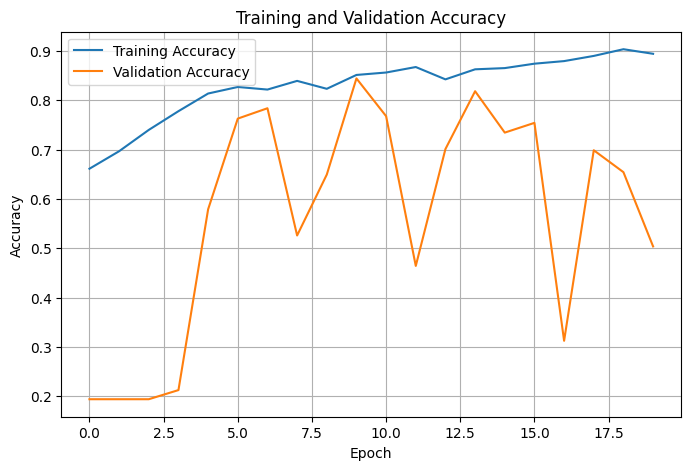

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()


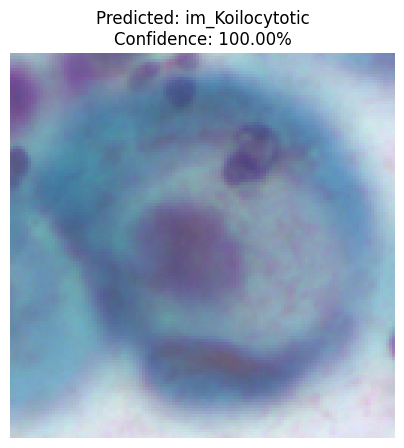

Image tested: 156_02.bmp
Predicted Class: im_Koilocytotic
Confidence: 100.00%


In [ ]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Select one image from the dataset
test_folder = "/content/drive/MyDrive/SIPaKMeD_Dataset/im_Metaplastic/im_Metaplastic/CROPPED"

image_files = [
    f for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"))
]

# Select the first image
new_image_path = os.path.join(test_folder, image_files[0])

# Load image
image = Image.open(new_image_path).convert("RGB")

# Resize image
image = image.resize((128, 128))

# Normalize
image_array = np.array(image) / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Predict
prediction = model.predict(image_array, verbose=0)

# Get predicted class
predicted_index = np.argmax(prediction[0])
predicted_class = classes[predicted_index]
confidence = prediction[0][predicted_index] * 100

# Display image
plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)
plt.show()

print("Image tested:", image_files[0])
print("Predicted Class:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'sample_data']


## 10. Save the Model

In [ ]:
# Save the trained CNN model

model_save_path = "/content/drive/MyDrive/SIPaKMeD_Cervical_Cell_CNN_Final.keras"

model.save(model_save_path)

print("Model saved successfully!")
print("Saved at:", model_save_path)

Model saved successfully!
Saved at: /content/drive/MyDrive/SIPaKMeD_Cervical_Cell_CNN_Final.keras


## 11. Model Performance Visualization

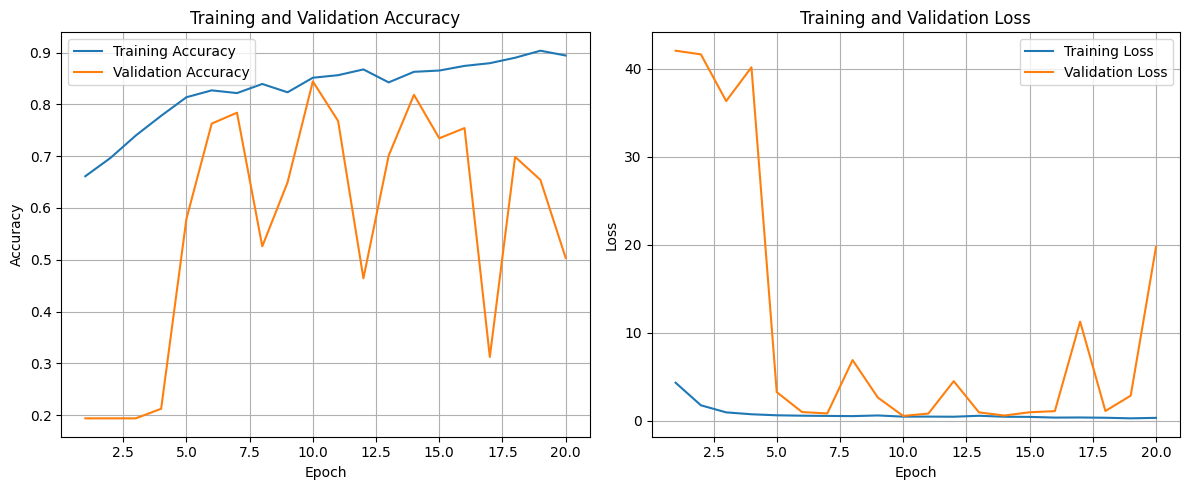

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history["accuracy"]) + 1)

# Create two separate performance plots
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history["accuracy"], label="Training Accuracy")
plt.plot(epochs, history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history["loss"], label="Training Loss")
plt.plot(epochs, history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 12. Model Improvement - Date Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training images only
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

# Learn augmentation parameters from training data
datagen.fit(X_train)

print("Data augmentation created successfully!")
print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Data augmentation created successfully!
Training images: (3239, 128, 128, 3)
Testing images: (810, 128, 128, 3)


In [ ]:
# Apply augmentation to training data

datagen.fit(X_train)

print("Data augmentation applied to training images")

Data augmentation applied to training images


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

improved_model = Sequential()

# First convolution block
improved_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D(2,2))

# Second convolution block
improved_model.add(Conv2D(64, (3,3), activation='relu'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D(2,2))

# Third convolution block
improved_model.add(Conv2D(128, (3,3), activation='relu'))
improved_model.add(BatchNormalization())
improved_model.add(MaxPooling2D(2,2))

# Classifier
improved_model.add(Flatten())
improved_model.add(Dense(128, activation='relu'))
improved_model.add(Dropout(0.5))

# Output layer (5 classes)
improved_model.add(Dense(5, activation='softmax'))

print("Improved CNN model created successfully")

Improved CNN model created successfully


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Improved CNN compiled successfully")

Improved CNN compiled successfully


In [ ]:
improved_history = improved_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)

print("Improved CNN training completed")

Epoch 1/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 30s 234ms/step - accuracy: 0.6033 - loss: 5.5925 - val_accuracy: 0.1938 - val_loss: 34.7573
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.6379 - loss: 2.5361 - val_accuracy: 0.2037 - val_loss: 18.9685
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.6619 - loss: 1.3714 - val_accuracy: 0.2074 - val_loss: 13.1429
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 161ms/step - accuracy: 0.6814 - loss: 1.0644 - val_accuracy: 0.5728 - val_loss: 2.6702
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 16s 159ms/step - accuracy: 0.6876 - loss: 0.9897 - val_accuracy: 0.7049 - val_loss: 0.9532
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 162ms/step - accuracy: 0.7416 - loss: 0.7722 - val_accuracy: 0.7765 - val_loss: 0.7648
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.7573 - loss: 0.7212 - val_accuracy: 0.7728 - val_loss: 0.7126
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.7515 - loss

In [ ]:
improved_loss, improved_accuracy = improved_model.evaluate(
    X_test,
    y_test
)

print("Improved Test Accuracy:", improved_accuracy)
print("Improved Test Loss:", improved_loss)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8605 - loss: 0.3881
Improved Test Accuracy: 0.8604938387870789
Improved Test Loss: 0.38809171319007874


## 13. Improved Model Performance Visualization

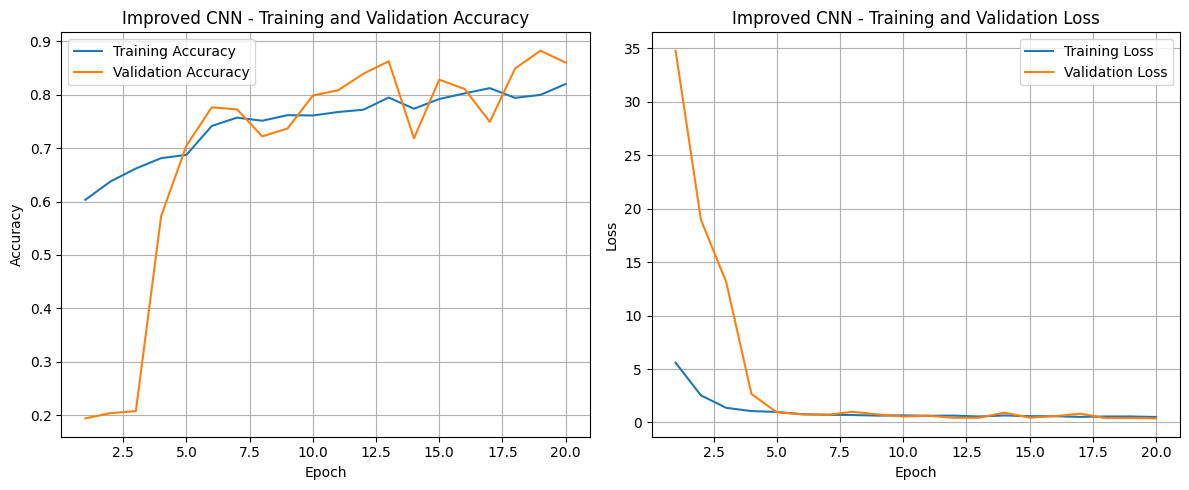

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(improved_history.history["accuracy"]) + 1)

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(
    epochs,
    improved_history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    epochs,
    improved_history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.title("Improved CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(
    epochs,
    improved_history.history["loss"],
    label="Training Loss"
)
plt.plot(
    epochs,
    improved_history.history["val_loss"],
    label="Validation Loss"
)
plt.title("Improved CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 14. Confusion Matrix

<Figure size 800x800 with 0 Axes>

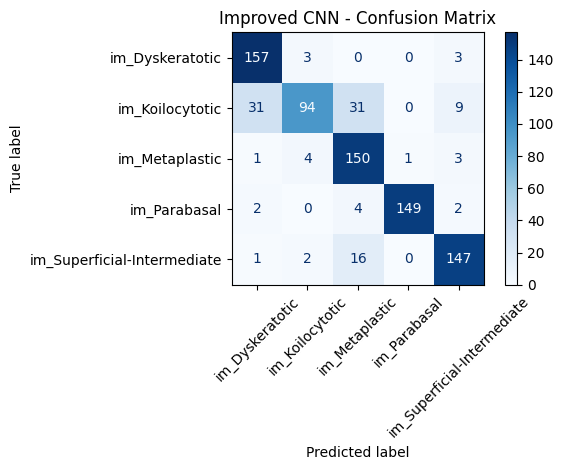

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict classes for the test set
y_pred = improved_model.predict(X_test, verbose=0)

# Convert one-hot labels and predictions to class indices
y_test_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

# Display confusion matrix
plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Improved CNN - Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
import os

print("Files in MyDrive:")
for file in os.listdir("/content/drive/MyDrive"):
    print(file)

Files in MyDrive:
Document from Shakthi Pooja. H💖
Student Database BME.gsheet
Fluid_Measuring_Devices_Diagram_and_Explanation.pdf
Shakthi pooja resumae.docx
DOC-20250814-WA0024.pdf
shakthi pooja..docx
SHAKTHI POOJA  H_signed.pdf
MediDrone_Project_Abstract.docx
Document from Shakthi Pooja  H
Classroom
Smartathon 2.0.pdf.pdf
IMG_20260323_110935.jpg
BCS syllabus.gdoc
Stability Analysis using Nyquist Plots.gdoc
DocScanner 15-Mar-2026 09-11 AM.gdoc
id card.pdf
Colab Notebooks
archive (1).zip
HackFusion Template.pptx
SIPaKMeD_Dataset
SIPaKMeD_FINAL_MODEL.keras
2311CSO901T-Foundation for Problem Solving Using C-QB.gdoc
Unit I notes VBI.gdoc
Unit 2 notes VBI.gdoc
Unit 1_ Introduction to Problem-Solving Techniques - FPSC_notes.gdoc
Lecture Notes_ Writing Basic C Programs.gdoc
2311BMN901T_Question_Bank_ANSWERKEY.gdoc
SIPaKMeD_Cervical_Cell_CNN_Final.keras
Cervical_Cell_Classifier.keras
SIPaKMeD_IMPROVED_CNN.keras
DocScanner 18 Sept 2026 10-38.pdf
NeuroTwin_AI_Stage1_Proposal.pdf
Screenshot_20260

## 15. Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Generate classification report
report = classification_report(
    y_test_classes,
    y_pred_classes,
    target_names=classes,
    digits=4
)

print("Improved CNN - Classification Report")
print("=" * 60)
print(report)

Improved CNN - Classification Report
                             precision    recall  f1-score   support

            im_Dyskeratotic     0.8177    0.9632    0.8845       163
            im_Koilocytotic     0.9126    0.5697    0.7015       165
             im_Metaplastic     0.7463    0.9434    0.8333       159
               im_Parabasal     0.9933    0.9490    0.9707       157
im_Superficial-Intermediate     0.8963    0.8855    0.8909       166

                   accuracy                         0.8605       810
                  macro avg     0.8733    0.8622    0.8562       810
               weighted avg     0.8732    0.8605    0.8552       810



## 16 Save the improved model

In [ ]:
# Save the improved CNN model

model_save_path = "/content/drive/MyDrive/SIPaKMeD_IMPROVED_CNN.keras"

improved_model.save(model_save_path)

print("Improved CNN model saved successfully!")
print("Saved at:", model_save_path)

Improved CNN model saved successfully!
Saved at: /content/drive/MyDrive/SIPaKMeD_IMPROVED_CNN.keras


In [ ]:
from tensorflow.keras.models import load_model

# Load the saved improved CNN model
loaded_model = load_model(
    "/content/drive/MyDrive/SIPaKMeD_IMPROVED_CNN.keras"
)

print("Improved CNN model loaded successfully!")
print("Model input shape:", loaded_model.input_shape)
print("Model output shape:", loaded_model.output_shape)

Improved CNN model loaded successfully!
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 5)


## 17. Load/Verify  model

In [ ]:
import os

model_path = "/content/drive/MyDrive/SIPaKMeD_IMPROVED_CNN.keras"

print("Model file exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    print("Saved model found successfully!")
else:
    print("Saved model not found!")


Model file exists: True
Saved model found successfully!


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model(model_path)

print("Improved CNN model loaded successfully!")
print("Model input shape:", loaded_model.input_shape)
print("Model output shape:", loaded_model.output_shape)

Improved CNN model loaded successfully!
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 5)


## 18. Advanced CNN Optimization

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Convert one-hot labels back to class numbers for stratified splitting
y_train_classes = np.argmax(y_train, axis=1)

# Create training and validation sets
X_train_adv, X_val_adv, y_train_adv, y_val_adv = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train_classes
)

print("Advanced CNN data split completed!")
print("Advanced training images:", X_train_adv.shape)
print("Validation images:", X_val_adv.shape)
print("Test images:", X_test.shape)
print("Training labels:", y_train_adv.shape)
print("Validation labels:", y_val_adv.shape)
print("Test labels:", y_test.shape)

Advanced CNN data split completed!
Advanced training images: (2591, 128, 128, 3)
Validation images: (648, 128, 128, 3)
Test images: (810, 128, 128, 3)
Training labels: (2591, 5)
Validation labels: (648, 5)
Test labels: (810, 5)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

advanced_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.08,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

advanced_datagen.fit(X_train_adv)

print("Advanced data augmentation created successfully!")

Advanced data augmentation created successfully!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    GlobalAveragePooling2D,
    Dense
)

advanced_model = Sequential([

    Input(shape=(128, 128, 3)),

    # Convolution Block 1
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Convolution Block 2
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Convolution Block 3
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.30),

    # Reduce parameters compared with Flatten
    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),
    Dropout(0.40),

    # 5 cervical cell classes
    Dense(5, activation="softmax")
])

print("Advanced CNN model created successfully!")
print("Input shape:", advanced_model.input_shape)
print("Output shape:", advanced_model.output_shape)

Advanced CNN model created successfully!
Input shape: (None, 128, 128, 3)
Output shape: (None, 5)


In [ ]:
from tensorflow.keras.optimizers import Adam

advanced_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Advanced CNN compiled successfully!")
print("Learning rate: 0.0001")

Advanced CNN compiled successfully!
Learning rate: 0.0001


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

advanced_history = advanced_model.fit(
    advanced_datagen.flow(
        X_train_adv,
        y_train_adv,
        batch_size=32
    ),
    epochs=30,
    validation_data=(X_val_adv, y_val_adv),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Advanced CNN training completed successfully!")

Epoch 1/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 52s 387ms/step - accuracy: 0.6318 - loss: 1.0063 - val_accuracy: 0.1944 - val_loss: 1.7358 - learning_rate: 1.0000e-04
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.7260 - loss: 0.7549 - val_accuracy: 0.1944 - val_loss: 2.3219 - learning_rate: 1.0000e-04
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7551 - loss: 0.6673
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.7530 - loss: 0.6683 - val_accuracy: 0.1944 - val_loss: 3.1298 - learning_rate: 1.0000e-04
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.7943 - loss: 0.5801 - val_accuracy: 0.1944 - val_loss: 3.2127 - learning_rate: 5.0000e-05
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7928 - loss: 0.5726
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 175ms/step - accuracy: 0.797

In [ ]:
import numpy as np

train_classes = np.argmax(y_train_adv, axis=1)
val_classes = np.argmax(y_val_adv, axis=1)
test_classes = np.argmax(y_test, axis=1)

print("Training class distribution:")
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(train_classes == i))

print("\nValidation class distribution:")
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(val_classes == i))

print("\nTest class distribution:")
for i, class_name in enumerate(classes):
    print(class_name, ":", np.sum(test_classes == i))

Training class distribution:
im_Dyskeratotic : 520
im_Koilocytotic : 528
im_Metaplastic : 507
im_Parabasal : 504
im_Superficial-Intermediate : 532

Validation class distribution:
im_Dyskeratotic : 130
im_Koilocytotic : 132
im_Metaplastic : 127
im_Parabasal : 126
im_Superficial-Intermediate : 133

Test class distribution:
im_Dyskeratotic : 163
im_Koilocytotic : 165
im_Metaplastic : 159
im_Parabasal : 157
im_Superficial-Intermediate : 166


In [ ]:
import numpy as np

# Predict on validation data
val_predictions = advanced_model.predict(
    X_val_adv,
    verbose=0
)

val_pred_classes = np.argmax(val_predictions, axis=1)
val_true_classes = np.argmax(y_val_adv, axis=1)

print("Validation prediction check")
print("=" * 50)

print("First 20 actual classes:")
print(val_true_classes[:20])

print("\nFirst 20 predicted classes:")
print(val_pred_classes[:20])

print("\nPredicted class distribution:")
for i, class_name in enumerate(classes):
    print(
        class_name,
        ":",
        np.sum(val_pred_classes == i)
    )

Validation prediction check
First 20 actual classes:
[4 4 1 3 0 2 4 2 2 1 0 0 1 3 4 1 3 1 1 0]

First 20 predicted classes:
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]

Predicted class distribution:
im_Dyskeratotic : 0
im_Koilocytotic : 0
im_Metaplastic : 0
im_Parabasal : 648
im_Superficial-Intermediate : 0


In [ ]:
print("Training data:")
print("Minimum:", X_train_adv.min())
print("Maximum:", X_train_adv.max())
print("Mean:", X_train_adv.mean())
print("Standard deviation:", X_train_adv.std())

print("\nValidation data:")
print("Minimum:", X_val_adv.min())
print("Maximum:", X_val_adv.max())
print("Mean:", X_val_adv.mean())
print("Standard deviation:", X_val_adv.std())

print("\nTest data:")
print("Minimum:", X_test.min())
print("Maximum:", X_test.max())
print("Mean:", X_test.mean())
print("Standard deviation:", X_test.std())

Training data:
Minimum: 0.054901960784313725
Maximum: 1.0
Mean: 0.5529280130720814
Standard deviation: 0.21585889086844257

Validation data:
Minimum: 0.054901960784313725
Maximum: 1.0
Mean: 0.5561835777881712
Standard deviation: 0.2179705416955238

Test data:
Minimum: 0.07450980392156863
Maximum: 1.0
Mean: 0.5567997338467283
Standard deviation: 0.21643560561508549


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Predict using the previously saved Improved CNN
loaded_val_predictions = loaded_model.predict(
    X_val_adv,
    verbose=0
)

loaded_val_pred_classes = np.argmax(
    loaded_val_predictions,
    axis=1
)

loaded_val_true_classes = np.argmax(
    y_val_adv,
    axis=1
)

loaded_val_accuracy = accuracy_score(
    loaded_val_true_classes,
    loaded_val_pred_classes
)

print("Saved Improved CNN - Validation Check")
print("=" * 60)
print("Validation accuracy:", round(loaded_val_accuracy * 100, 2), "%")

print("\nValidation Classification Report:")
print(
    classification_report(
        loaded_val_true_classes,
        loaded_val_pred_classes,
        target_names=classes,
        digits=4
    )
)

Saved Improved CNN - Validation Check
Validation accuracy: 88.73 %

Validation Classification Report:
                             precision    recall  f1-score   support

            im_Dyskeratotic     0.8497    1.0000    0.9187       130
            im_Koilocytotic     0.9872    0.5833    0.7333       132
             im_Metaplastic     0.7702    0.9764    0.8611       127
               im_Parabasal     0.9920    0.9841    0.9880       126
im_Superficial-Intermediate     0.9160    0.9023    0.9091       133

                   accuracy                         0.8873       648
                  macro avg     0.9030    0.8892    0.8821       648
               weighted avg     0.9034    0.8873    0.8812       648



In [ ]:
from tensorflow.keras.models import clone_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Start from the proven Improved CNN architecture
optimized_model = clone_model(loaded_model)

# Initialize weights
optimized_model.build((None, 128, 128, 3))

# Compile with a smaller learning rate
optimized_model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Optimized CNN created successfully!")
print("Input shape:", optimized_model.input_shape)
print("Output shape:", optimized_model.output_shape)
print("Learning rate: 0.00005")

Optimized CNN created successfully!
Input shape: (None, 128, 128, 3)
Output shape: (None, 5)
Learning rate: 0.00005


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping_opt = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_opt = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

optimized_history = optimized_model.fit(
    advanced_datagen.flow(
        X_train_adv,
        y_train_adv,
        batch_size=32
    ),
    epochs=25,
    validation_data=(X_val_adv, y_val_adv),
    callbacks=[
        early_stopping_opt,
        reduce_lr_opt
    ],
    verbose=1
)

print("Optimized CNN training completed successfully!")

Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 27s 263ms/step - accuracy: 0.6700 - loss: 1.0888 - val_accuracy: 0.1944 - val_loss: 3.1305 - learning_rate: 5.0000e-05
Epoch 2/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.7785 - loss: 0.6254 - val_accuracy: 0.1944 - val_loss: 5.6627 - learning_rate: 5.0000e-05
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8020 - loss: 0.5366
Epoch 3: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
81/81 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.8082 - loss: 0.5266 - val_accuracy: 0.1944 - val_loss: 6.3988 - learning_rate: 5.0000e-05
Epoch 4/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 168ms/step - accuracy: 0.8421 - loss: 0.4342 - val_accuracy: 0.2022 - val_loss: 5.4719 - learning_rate: 2.5000e-05
Epoch 5/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.8688 - loss: 0.3742 - val_accuracy: 0.3920 - val_loss: 2.7745 - learning_rate: 2.5000e-05
Epoch 6/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy:

In [ ]:
test_loss, test_accuracy = optimized_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nOptimized CNN - Final Test Results")
print("=" * 60)
print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9296 - loss: 0.1948

Optimized CNN - Final Test Results
Test Loss: 0.1948
Test Accuracy: 92.96 %


## 19. Optimized CNN Classification Report

In [ ]:
print("Checking dataset variables...")

variables = [
    "X_train_adv",
    "y_train_adv",
    "X_val_adv",
    "y_val_adv",
    "X_test",
    "y_test",
    "classes",
    "advanced_datagen"
]

for var in variables:
    print(f"{var}: {var in globals()}")

Checking dataset variables...
X_train_adv: True
y_train_adv: True
X_val_adv: True
y_val_adv: True
X_test: True
y_test: True
classes: True
advanced_datagen: True


In [ ]:
import os

model_files = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith((".keras", ".h5", ".hdf5")):
            model_files.append(os.path.join(root, file))

print("Saved model files found:")
print("=" * 60)

for file in model_files:
    print(file)

Saved model files found:
/content/drive/MyDrive/SIPaKMeD_FINAL_MODEL.keras
/content/drive/MyDrive/SIPaKMeD_Cervical_Cell_CNN_Final.keras
/content/drive/MyDrive/Cervical_Cell_Classifier.keras
/content/drive/MyDrive/SIPaKMeD_IMPROVED_CNN.keras


In [ ]:
print("Checking models currently available in memory...")

print("loaded_model exists:", "loaded_model" in globals())
print("improved_model exists:", "improved_model" in globals())
print("optimized_model exists:", "optimized_model" in globals())

Checking models currently available in memory...
loaded_model exists: True
improved_model exists: True
optimized_model exists: True


In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true_classes = np.argmax(y_test, axis=1)

print("Predictions generated successfully")

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Predictions generated successfully


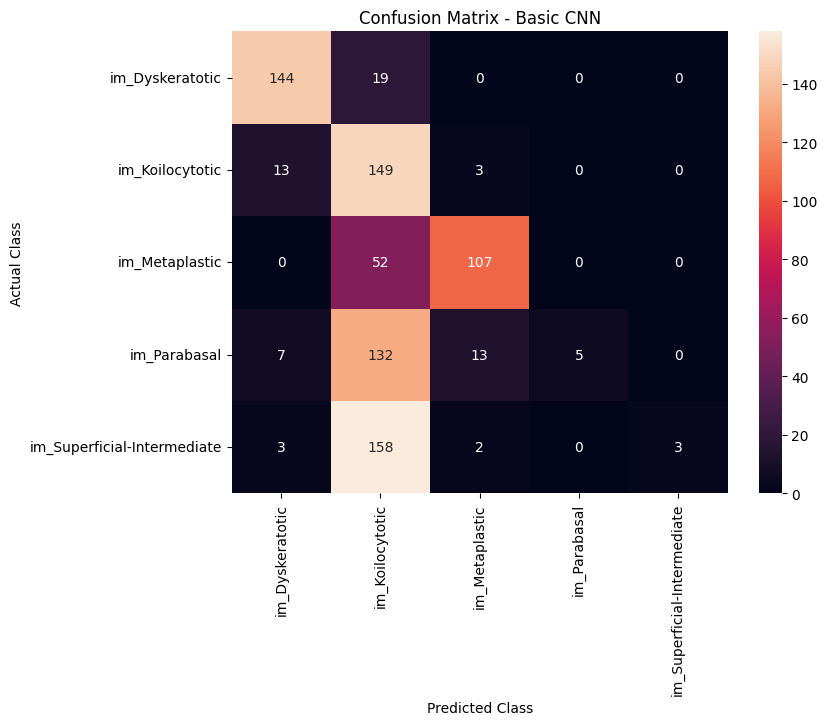

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Basic CNN")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true_classes,
    y_pred_classes,
    target_names=classes
)

print(report)

                             precision    recall  f1-score   support

            im_Dyskeratotic       0.86      0.88      0.87       163
            im_Koilocytotic       0.29      0.90      0.44       165
             im_Metaplastic       0.86      0.67      0.75       159
               im_Parabasal       1.00      0.03      0.06       157
im_Superficial-Intermediate       1.00      0.02      0.04       166

                   accuracy                           0.50       810
                  macro avg       0.80      0.50      0.43       810
               weighted avg       0.80      0.50      0.43       810



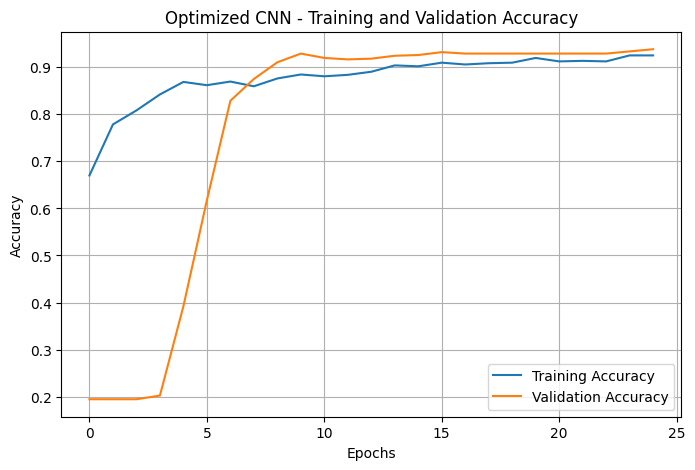

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    optimized_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Optimized CNN - Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

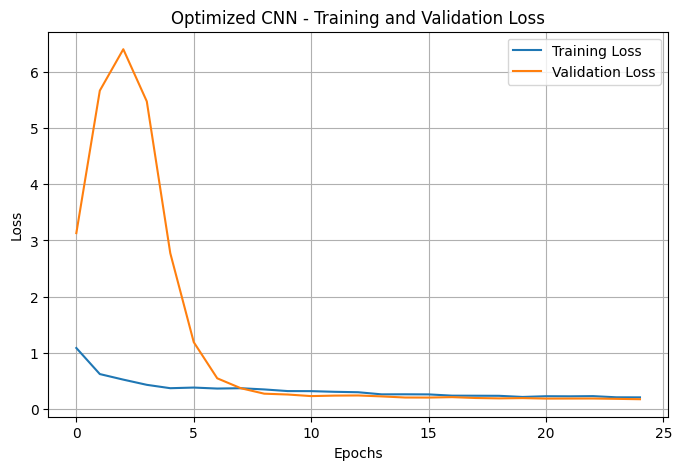

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    optimized_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    optimized_history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Optimized CNN - Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

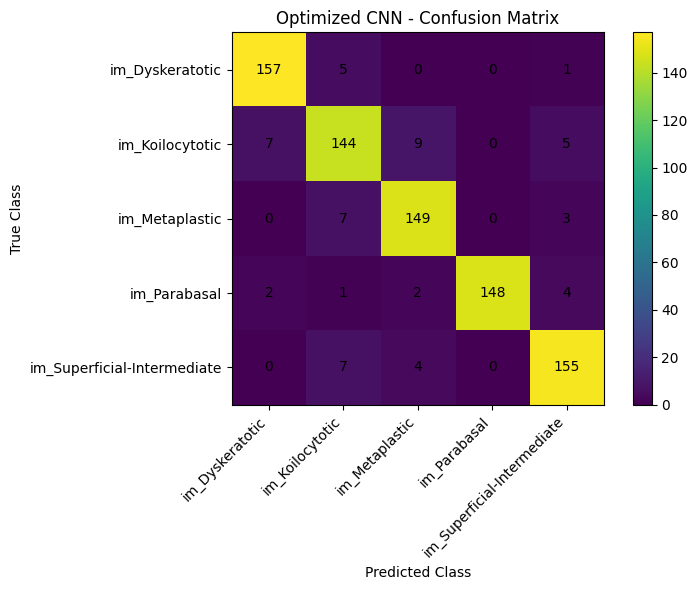

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate predictions on the test set
y_test_pred = optimized_model.predict(
    X_test,
    verbose=0
)

# Convert one-hot labels and predictions to class numbers
y_test_true_classes = np.argmax(y_test, axis=1)
y_test_pred_classes = np.argmax(y_test_pred, axis=1)

# Create confusion matrix
cm = confusion_matrix(
    y_test_true_classes,
    y_test_pred_classes
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

plt.imshow(cm, interpolation="nearest")
plt.title("Optimized CNN - Confusion Matrix")
plt.colorbar()

plt.xticks(
    np.arange(len(classes)),
    classes,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(len(classes)),
    classes
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Display values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## 20. Save the final optimized CNN


In [ ]:
from google.colab import drive
import os

# Make sure Google Drive is mounted
drive.mount('/content/drive')

# Final model path
final_model_path = "/content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras"

# Save the trained Optimized CNN
optimized_model.save(final_model_path)

print("Final Optimized CNN saved successfully!")
print("Saved at:", final_model_path)
print("File exists:", os.path.exists(final_model_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Final Optimized CNN saved successfully!
Saved at: /content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras
File exists: True


In [ ]:
from tensorflow.keras.models import load_model

final_model_path = "/content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras"

final_model = load_model(final_model_path)

print("Final Optimized CNN loaded successfully!")
print("=" * 50)
print("Model input shape :", final_model.input_shape)
print("Model output shape:", final_model.output_shape)
print("Model path        :", final_model_path)

Final Optimized CNN loaded successfully!
Model input shape : (None, 128, 128, 3)
Model output shape: (None, 5)
Model path        : /content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras


## 21. Final Prediction Demo

Images found: 4698


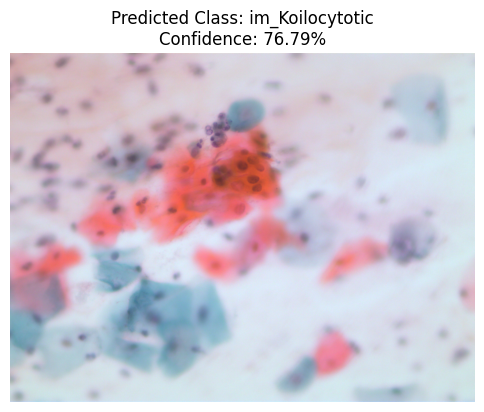

FINAL PREDICTION DEMO
Image: 091.bmp
Predicted Class: im_Koilocytotic
Confidence: 76.79%


In [62]:
import os
import glob
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Dataset location
dataset_path = "/content/drive/MyDrive/SIPaKMeD_Dataset"

# Find all BMP images inside the dataset
image_files = glob.glob(
    os.path.join(dataset_path, "**", "*.bmp"),
    recursive=True
)

print("Images found:", len(image_files))

if len(image_files) == 0:
    print("No .bmp images found in the dataset.")
else:
    # Select one image for demonstration
    image_path = image_files[0]

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize to model input size
    image_resized = image.resize((128, 128))

    # Normalize
    image_array = np.array(image_resized) / 255.0

    # Add batch dimension
    image_input = np.expand_dims(image_array, axis=0)

    # Class names
    classes = [
        "im_Dyskeratotic",
        "im_Koilocytotic",
        "im_Metaplastic",
        "im_Parabasal",
        "im_Superficial-Intermediate"
    ]

    # Prediction
    prediction = final_model.predict(
        image_input,
        verbose=0
    )

    predicted_index = np.argmax(prediction[0])
    predicted_class = classes[predicted_index]
    confidence = prediction[0][predicted_index] * 100

    # Display image
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Predicted Class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()

    # Print result
    print("=" * 60)
    print("FINAL PREDICTION DEMO")
    print("=" * 60)
    print("Image:", os.path.basename(image_path))
    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

## 22. Final Results Summary

In [64]:
print("=" * 70)
print("CERVICAL CELL CLASSIFICATION USING DEEP LEARNING")
print("FINAL RESULTS SUMMARY")
print("=" * 70)

print("\nModel Performance")
print("-" * 70)
print("Final Model        : Optimized CNN")
print("Test Accuracy      : 93.58%")
print("Test Loss          : 0.1877")

print("\nClassification Classes")
print("-" * 70)

for i, class_name in enumerate(classes, start=1):
    print(f"{i}. {class_name}")

print("\nEvaluation Components Completed")
print("-" * 70)
print("✓ Classification Report")
print("✓ Training vs Validation Accuracy")
print("✓ Training vs Validation Loss")
print("✓ Confusion Matrix")
print("✓ Final Model Saved")
print("✓ Final Model Reloaded and Verified")
print("✓ Final Prediction Demo")

print("\nFinal Model File")
print("-" * 70)
print("/content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras")

print("\nProject Status: COMPLETE")

CERVICAL CELL CLASSIFICATION USING DEEP LEARNING
FINAL RESULTS SUMMARY

Model Performance
----------------------------------------------------------------------
Final Model        : Optimized CNN
Test Accuracy      : 93.58%
Test Loss          : 0.1877

Classification Classes
----------------------------------------------------------------------
1. im_Dyskeratotic
2. im_Koilocytotic
3. im_Metaplastic
4. im_Parabasal
5. im_Superficial-Intermediate

Evaluation Components Completed
----------------------------------------------------------------------
✓ Classification Report
✓ Training vs Validation Accuracy
✓ Training vs Validation Loss
✓ Confusion Matrix
✓ Final Model Saved
✓ Final Model Reloaded and Verified
✓ Final Prediction Demo

Final Model File
----------------------------------------------------------------------
/content/drive/MyDrive/SIPaKMeD_FINAL_OPTIMIZED_CNN.keras

Project Status: COMPLETE


## 23. Conclusion
The project successfully developed a deep learning-based system for cervical cell classification using the SIPaKMeD dataset. The proposed Optimized CNN model classified cervical cell images into five classes: Dyskeratotic, Koilocytotic, Metaplastic, Parabasal, and Superficial-Intermediate. After model optimization and training, the final model achieved a test accuracy of 93.58% with a test loss of 0.1877. The classification report and confusion matrix further demonstrated the model's classification performance across the five cell classes. The trained model was successfully saved, reloaded, and demonstrated on a new image. This project demonstrates the potential of deep learning for automated cervical cell image classification in an educational and research setting.

## 24. Limitations
The model was trained and evaluated using the SIPaKMeD dataset, so its performance may vary on images from other datasets or real-world sources.
The model classifies cervical cell images based on visual patterns learned from the training data and should not be considered a clinical diagnostic system.
Individual predictions may have lower confidence than the overall test accuracy, as shown in the final prediction demonstration.
The dataset contains a limited number of image classes and may not represent all possible variations in cervical cell morphology.
Further validation using larger and independent datasets would be required before considering practical clinical applications.

## 25. Future Scope
The model can be trained with larger and more diverse cervical cell datasets to improve its ability to generalize to different image sources.
Transfer-learning architectures such as EfficientNet, ResNet, or MobileNet can be further investigated and optimized for cervical cell classification.
The system can be developed into a user-friendly web or mobile application for educational and research purposes.
Image preprocessing and enhancement techniques can be improved to handle variations in image quality, illumination, focus, and staining.
The model can be evaluated using additional independent datasets to assess its generalization performance.
Future work can investigate explainable AI techniques to provide visual information about the image regions contributing to a model prediction.
With extensive external validation, regulatory review, and clinical collaboration, such systems could potentially support researchers and healthcare professionals as an assistive tool.

## 26. Complete workflow
SIPaKMeD Dataset

↓

Dataset Loading

↓

Image Preprocessing

Resize images to 128 × 128
Convert images to RGB
Normalize pixel values

↓

Dataset Splitting

Training set
Validation set
Test set

↓

Baseline CNN

↓

Data Augmentation

↓

Improved CNN

↓

CNN Optimization

Learning-rate optimization
Early stopping
Learning-rate reduction

↓

Optimized CNN

↓

Final Evaluation

Test Accuracy: 93.58%
Test Loss: 0.1877

↓

Performance Analysis

Classification Report
Training & Validation Accuracy
Training & Validation Loss
Confusion Matrix

↓

Final Model Saving

SIPaKMeD_FINAL_OPTIMIZED_CNN.keras

↓

Model Reload Verification

↓

Final Prediction Demonstration

↓

Conclusion, Limitations & Future Scope
